# Indonesian Sentiment Analyst


In [1]:
import csv
import html
import json
import pickle
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

DATA_DIR = Path('data/raw')
MODELS_DIR = Path('models')
REPORTS_DIR = Path('reports')

MODELS_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)


## Text Preprocessing

In [2]:
STOPWORDS_ID = {
    'ada', 'adalah', 'agar', 'akan', 'aku', 'anda', 'antara', 'apa', 'atau',
    'bagi', 'bahwa', 'dan', 'dari', 'dengan', 'di', 'dia', 'ini', 'itu',
    'jadi', 'juga', 'karena', 'ke', 'kita', 'maka', 'mereka', 'oleh', 'pada',
    'saat', 'saya', 'sebagai', 'sebuah', 'sehingga', 'untuk', 'yang',
}

def load_slang_dictionary(path):
    mapping = {}
    if not Path(path).exists():
        return mapping
    with open(path, 'r', encoding='utf-8', newline='') as handle:
        reader = csv.DictReader(handle)
        for row in reader:
            slang = (row.get('slang') or '').strip().lower()
            formal = (row.get('formal') or '').strip().lower()
            if slang and formal:
                mapping[slang] = formal
    return mapping

def normalize_text(text, slang_map=None):
    value = html.unescape(str(text).lower())
    value = re.sub(r'https?://\S+|www\.\S+', ' ', value)
    value = re.sub(r'@\w+', ' user ', value)
    value = re.sub(r'#', ' ', value)
    value = re.sub(r'(.)\1{2,}', r'\1\1', value)
    value = re.sub(r'[^0-9a-zA-Z_]+', ' ', value)
    tokens = [slang_map.get(token, token) for token in value.split()] if slang_map else value.split()
    return ' '.join(tokens)

def tokenize(text, slang_map=None, remove_stopwords=True):
    text = normalize_text(text, slang_map)
    tokens = re.findall(r'[a-zA-Z_][a-zA-Z_0-9]*', text)
    if remove_stopwords:
        tokens = [token for token in tokens if token not in STOPWORDS_ID and len(token) > 1]
    return tokens

def split_sentences(text):
    text = re.sub(r'\s+', ' ', str(text or '')).strip()
    if not text:
        return []
    parts = re.split(r'(?<=[.!?])\s+|(?<=\n)\s*', text)
    return [part.strip() for part in parts if part and part.strip()]


## Dataset Loading

In [3]:
def read_jsonl(path):
    rows = []
    with open(path, 'r', encoding='utf-8') as handle:
        for line_no, line in enumerate(handle, start=1):
            line = line.strip()
            if line:
                item = json.loads(line)
                item['_line_no'] = line_no
                rows.append(item)
    return rows

def load_indosum(data_dir):
    frames = []
    for split in ['train', 'dev', 'test']:
        path = Path(data_dir) / f'indosum_{split}_00.jsonl'
        if not path.exists():
            continue
        records = []
        for item in read_jsonl(path):
            paragraph = item.get('paragraph', '')
            summary = item.get('summary', '')
            records.append({
                'source': 'indosum',
                'split': split,
                'text': f'{paragraph} {summary}'.strip(),
                'paragraph': paragraph,
                'summary': summary,
            })
        frames.append(pd.DataFrame(records))
    if not frames:
        return pd.DataFrame(columns=['source', 'split', 'text', 'paragraph', 'summary'])
    return pd.concat(frames, ignore_index=True)

LABEL_MAP = {
    0: 'positive',
    1: 'neutral',
    2: 'negative',
}

LABELS = ['positive', 'neutral', 'negative']

def load_ppkm_sentiment(data_dir, slang_map=None):
    path = Path(data_dir) / 'ppkm_sentiment' / 'INA_TweetsPPKM_Labeled_Pure.csv'
    df = pd.read_csv(path, sep='\t')
    df = df.dropna(subset=['Tweet', 'sentiment']).copy()
    df['sentiment'] = df['sentiment'].astype(int)
    df = df[df['sentiment'].isin(LABEL_MAP)].copy()
    df['label'] = df['sentiment'].map(LABEL_MAP)
    df['normalized_tweet'] = df['Tweet'].map(lambda text: normalize_text(text, slang_map=slang_map))
    df = df[df['normalized_tweet'].str.strip() != ''].reset_index(drop=True)
    return df

slang_map = load_slang_dictionary(DATA_DIR / 'slang_dictionary.csv')
ppkm_df = load_ppkm_sentiment(DATA_DIR, slang_map=slang_map)
indosum_df = load_indosum(DATA_DIR)

print('PPKM labeled rows:', len(ppkm_df))
print(ppkm_df['label'].value_counts())
print('IndoSum rows for summarization:', len(indosum_df))
ppkm_df.head()


PPKM labeled rows: 23644
label
neutral     17706
negative     3980
positive     1958
Name: count, dtype: int64
IndoSum rows for summarization: 18774


,Date,User,Tweet,sentiment,label,normalized_tweet
0,2022-03-31 14:32:04+00:00,pikobar_jabar,Ketahui informasi pembagian #PPKM di wilayah J...,1,neutral,ketahui informasi pembagian ppkm di wilayah ja...
1,2022-03-31 09:26:00+00:00,inewsdotid,Tempat Ibadah di Wilayah PPKM Level 1 Boleh Be...,1,neutral,tempat ibadah di wilayah ppkm level 1 boleh be...
2,2022-03-31 05:02:34+00:00,vdvc_talk,"Juru bicara Satgas Covid-19, Wiku Adisasmito m...",1,neutral,juru bicara satuan tugas covid 19 wiku adisasm...
3,2022-03-30 14:23:10+00:00,pikobar_jabar,Ketahui informasi pembagian #PPKM di wilayah J...,1,neutral,ketahui informasi pembagian ppkm di wilayah ja...
4,2022-03-30 11:28:57+00:00,tvOneNews,Kementerian Agama menerbitkan Surat Edaran Nom...,1,neutral,kementerian agama menerbitkan surat edaran nom...


## Supervised TF-IDF Sentiment Model

In [4]:
def build_sentiment_pipeline(max_features=30000, random_state=42):
    return Pipeline([
        ('tfidf', TfidfVectorizer(
            min_df=2,
            max_df=0.95,
            max_features=max_features,
            ngram_range=(1, 2),
            sublinear_tf=True,
            stop_words=list(STOPWORDS_ID),
        )),
        ('classifier', LogisticRegression(
            max_iter=1000,
            solver='lbfgs',
            class_weight='balanced',
            random_state=random_state,
        )),
    ])


In [5]:
RANDOM_STATE = 42
TEST_SIZE = 0.2
MAX_FEATURES = 30000

train_df, test_df = train_test_split(
    ppkm_df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=ppkm_df['label'],
)

sentiment_model = build_sentiment_pipeline(max_features=MAX_FEATURES, random_state=RANDOM_STATE)
sentiment_model.fit(train_df['normalized_tweet'], train_df['label'])

training_stats = {
    'documents': int(len(train_df)),
    'test_documents': int(len(test_df)),
    'positive_train_labels': int((train_df['label'] == 'positive').sum()),
    'neutral_train_labels': int((train_df['label'] == 'neutral').sum()),
    'negative_train_labels': int((train_df['label'] == 'negative').sum()),
    'vocabulary_size': int(len(sentiment_model.named_steps['tfidf'].get_feature_names_out())),
}
training_stats


{'documents': 18915,
 'test_documents': 4729,
 'positive_train_labels': 1566,
 'neutral_train_labels': 14165,
 'negative_train_labels': 3184,
 'vocabulary_size': 30000}

## LexRank and TextRank

In [6]:
def pagerank(similarity, damping=0.85, max_iter=100, tol=1e-6):
    n_items = similarity.shape[0]
    if n_items == 0:
        return np.array([])
    if n_items == 1:
        return np.array([1.0])

    weights = similarity.astype(float).copy()
    np.fill_diagonal(weights, 0.0)
    row_sums = weights.sum(axis=1)
    transition = np.zeros_like(weights)
    nonzero = row_sums > 0
    transition[nonzero] = weights[nonzero] / row_sums[nonzero, None]
    transition[~nonzero] = 1.0 / n_items

    scores = np.ones(n_items) / n_items
    teleport = np.ones(n_items) / n_items
    for _ in range(max_iter):
        updated = (1.0 - damping) * teleport + damping * transition.T.dot(scores)
        if np.abs(updated - scores).sum() < tol:
            return updated
        scores = updated
    return scores

def select_summary(sentences, scores, top_k):
    if len(sentences) <= top_k:
        return ' '.join(sentences)
    ranked = np.argsort(-scores)[:top_k]
    ranked = sorted(ranked.tolist())
    return ' '.join(sentences[index] for index in ranked)

def textrank_summary(text, vectorizer, slang_map=None, top_k=3):
    sentences = split_sentences(text)
    if len(sentences) <= top_k:
        return ' '.join(sentences)
    normalized = [normalize_text(sentence, slang_map) for sentence in sentences]
    matrix = vectorizer.transform(normalized)
    similarity = cosine_similarity(matrix)
    scores = pagerank(similarity)
    return select_summary(sentences, scores, top_k)

def lexrank_summary(text, vectorizer, slang_map=None, top_k=3, threshold=0.1):
    sentences = split_sentences(text)
    if len(sentences) <= top_k:
        return ' '.join(sentences)
    normalized = [normalize_text(sentence, slang_map) for sentence in sentences]
    matrix = vectorizer.transform(normalized)
    similarity = cosine_similarity(matrix)
    graph = np.where(similarity >= threshold, similarity, 0.0)
    scores = pagerank(graph)
    return select_summary(sentences, scores, top_k)

## Evaluate on Held-Out PPKM Test Set

Accuracy: 0.8422
Macro F1: 0.7384
Weighted F1: 0.8506
Confusion matrix rows=true ['positive', 'neutral', 'negative'], cols=predicted:
[[ 263   70   59]
 [ 215 3062  264]
 [  56   82  658]]
              precision    recall  f1-score   support

    positive       0.49      0.67      0.57       392
     neutral       0.95      0.86      0.91      3541
    negative       0.67      0.83      0.74       796

    accuracy                           0.84      4729
   macro avg       0.71      0.79      0.74      4729
weighted avg       0.87      0.84      0.85      4729



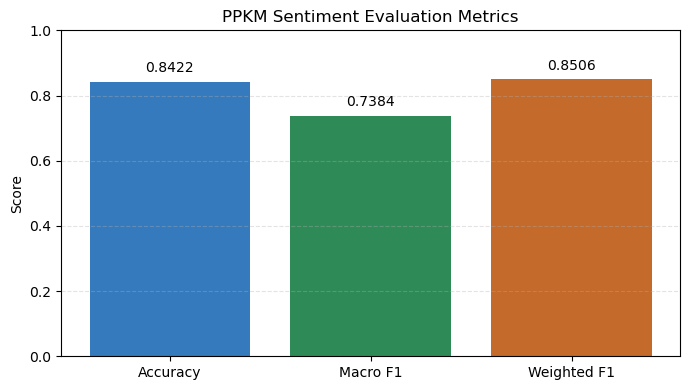

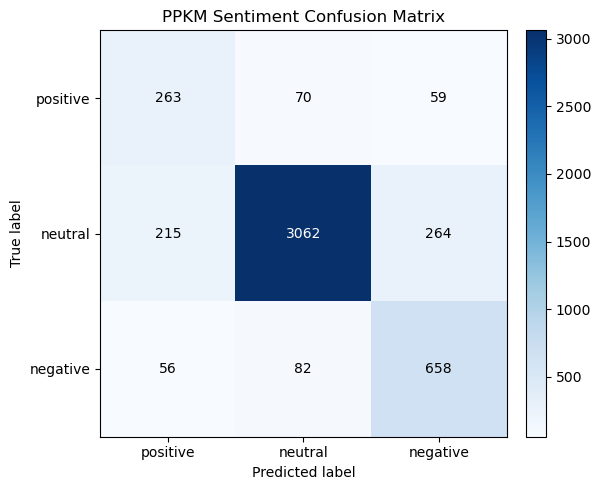

Saved matplotlib plots to reports\evaluation_metrics.png and reports\confusion_matrix.png


In [7]:
predicted_labels = sentiment_model.predict(test_df['normalized_tweet'])

if hasattr(sentiment_model.named_steps['classifier'], 'predict_proba'):
    probabilities = sentiment_model.predict_proba(test_df['normalized_tweet'])
    confidence = probabilities.max(axis=1)
else:
    confidence = np.nan

test_predictions = test_df.copy()
test_predictions['predicted_label'] = predicted_labels
test_predictions['confidence'] = confidence

accuracy = accuracy_score(test_predictions['label'], test_predictions['predicted_label'])
macro_f1 = f1_score(test_predictions['label'], test_predictions['predicted_label'], labels=LABELS, average='macro')
weighted_f1 = f1_score(test_predictions['label'], test_predictions['predicted_label'], labels=LABELS, average='weighted')
matrix = confusion_matrix(test_predictions['label'], test_predictions['predicted_label'], labels=LABELS)
metrics = {
    'accuracy': accuracy,
    'macro_f1': macro_f1,
    'weighted_f1': weighted_f1,
}
report = classification_report(
    test_predictions['label'],
    test_predictions['predicted_label'],
    labels=LABELS,
    zero_division=0,
)

print('Accuracy:', round(accuracy, 4))
print('Macro F1:', round(macro_f1, 4))
print('Weighted F1:', round(weighted_f1, 4))
print(f'Confusion matrix rows=true {LABELS}, cols=predicted:')
print(matrix)
print(report)

metric_names = ['Accuracy', 'Macro F1', 'Weighted F1']
metric_values = [metrics['accuracy'], metrics['macro_f1'], metrics['weighted_f1']]
metrics_plot = REPORTS_DIR / 'evaluation_metrics.png'

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(metric_names, metric_values, color=['#357ABD', '#2E8B57', '#C46A2B'])
ax.set_title('PPKM Sentiment Evaluation Metrics')
ax.set_ylabel('Score')
ax.set_ylim(0, 1)
ax.grid(axis='y', linestyle='--', alpha=0.35)
for bar, value in zip(bars, metric_values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 0.02, f'{value:.4f}', ha='center', va='bottom')
fig.tight_layout()
fig.savefig(metrics_plot, dpi=150)
plt.show()

confusion_plot = REPORTS_DIR / 'confusion_matrix.png'
fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(matrix, cmap='Blues')
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
ax.set_title('PPKM Sentiment Confusion Matrix')
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_xticks(range(len(LABELS)))
ax.set_xticklabels(LABELS)
ax.set_yticks(range(len(LABELS)))
ax.set_yticklabels(LABELS)
threshold = matrix.max() / 2 if matrix.size else 0
for row_index in range(matrix.shape[0]):
    for col_index in range(matrix.shape[1]):
        value = matrix[row_index, col_index]
        text_color = 'white' if value > threshold else 'black'
        ax.text(col_index, row_index, str(value), ha='center', va='center', color=text_color)
fig.tight_layout()
fig.savefig(confusion_plot, dpi=150)
plt.show()

print('Saved matplotlib plots to', metrics_plot, 'and', confusion_plot)


## Summary Examples

In [8]:
summary_records = []
summary_vectorizer = sentiment_model.named_steps['tfidf']

for _, row in indosum_df.head(5).iterrows():
    text = row['paragraph']
    summary_records.append({
        'original_summary': row['summary'],
        'lexrank_summary': lexrank_summary(text, summary_vectorizer, slang_map=slang_map, top_k=3),
        'textrank_summary': textrank_summary(text, summary_vectorizer, slang_map=slang_map, top_k=3),
    })

summary_examples = pd.DataFrame(summary_records)
summary_examples


,original_summary,lexrank_summary,textrank_summary
0,Dokter Lula Kamal yang merupakan selebriti sek...,"Jakarta, CNN Indonesia - - Dokter Ryan Thamrin...","Jakarta, CNN Indonesia - - Dokter Ryan Thamrin..."
1,Asus memperkenalkan ZenFone generasi keempat...,Mereka adalah Asus ZenFone 4 Selfie Pro ZD552K...,Mereka adalah Asus ZenFone 4 Selfie Pro ZD552K...
2,Dinas Pariwisata Provinsi Bengkulu kembali men...,"Jakarta, CNN Indonesia - - Dinas Pariwisata Pr...","Jakarta, CNN Indonesia - - Dinas Pariwisata Pr..."
3,Indonesia Corruption Watch (ICW) meminta Komis...,Merdeka.com - Indonesia Corruption Watch (ICW)...,Merdeka.com - Indonesia Corruption Watch (ICW)...
4,Jokowi memimpin upacara penurunan bendera. Usa...,"Usai prosesi penurunan bendera dilakukan, Joko...","Usai prosesi penurunan bendera dilakukan, Joko..."


## Save Model

In [9]:
model_path = MODELS_DIR / 'ppkm_sentiment_pipeline.pkl'

model_artifact = {
    'model': sentiment_model,
    'label_map': LABEL_MAP,
    'slang_map': slang_map,
    'metrics': metrics,
    'plots': {
        'evaluation_metrics': str(metrics_plot),
        'confusion_matrix': str(confusion_plot),
    },
}

with open(model_path, 'wb') as handle:
    pickle.dump(model_artifact, handle)

print('Saved model to', model_path)


Saved model to models\ppkm_sentiment_pipeline.pkl


## Preview Predictions

In [10]:
test_predictions[['Tweet', 'label', 'predicted_label', 'confidence']].head(10)

,Tweet,label,predicted_label,confidence
19958,"Bukannya tidak mau berkembang, melainkan keada...",negative,negative,0.789337
7955,"Ada kaum yg saking maniaknya dugem,lantaran #P...",negative,negative,0.466961
3830,Sablon #Custom Print Design Tees Pre Order Gif...,neutral,neutral,0.864250
9036,Panjang kuat dan tahan lama\n#ppkm,positive,negative,0.602358
4556,Menteri Koordinator (Menko) Bidang Perekonomia...,neutral,neutral,0.923636
22328,KUKAR - Kapolres Kukar AKBP Irwan Masulin Gint...,neutral,neutral,0.952562
7261,"Sobat BFI, buat kamu yang butuh dana besar di ...",positive,positive,0.691992
2516,Pemerintah terapkan PPKM level 3 di seluruh In...,neutral,neutral,0.931096
16665,"""Imigrasi Sibolga Melayani Sepenuh Hati"" \n\nH...",neutral,neutral,0.690387
21718,Bupati Bogor Akan Berikan Penghargaan Predikat...,neutral,neutral,0.899045
